Smart Factory Machinery Predictor

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import joblib

%matplotlib inline

In [18]:
data_path = r"dataset.csv"
df = pd.read_csv(data_path)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

Task 1: Simple Linear Regression

In [20]:
simple_df = df[["Rotational speed [rpm]", "Process temperature [K]"]].dropna()

X_simple = simple_df[["Rotational speed [rpm]"]]
y_temp = simple_df["Process temperature [K]"]

simple_model = LinearRegression()
simple_model.fit(X_simple, y_temp)

simple_preds = simple_model.predict(X_simple)
simple_mse = mean_squared_error(y_temp, simple_preds)

print("Simple Linear Regression MSE:", round(simple_mse, 4))
print("Intercept:", round(simple_model.intercept_, 4))
print("RPM coefficient:", round(simple_model.coef_[0], 6))

Simple Linear Regression MSE: 2.2004
Intercept: 309.7601
RPM coefficient: 0.00016


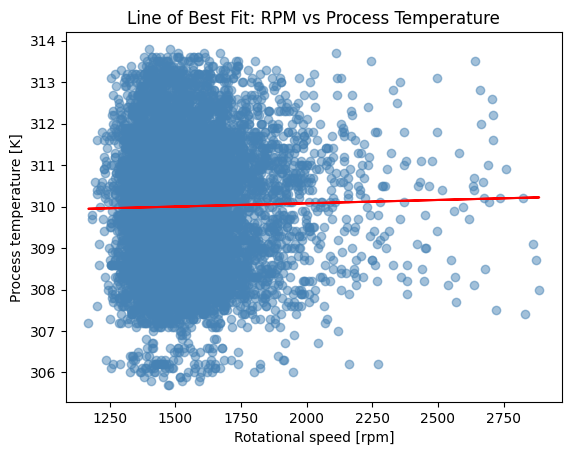

In [21]:
plt.scatter(X_simple, y_temp, color="steelblue", alpha=0.5)
plt.plot(X_simple, simple_preds, color="red")
plt.xlabel("Rotational speed [rpm]")
plt.ylabel("Process temperature [K]")
plt.title("Line of Best Fit: RPM vs Process Temperature")
plt.show()

Task 2: Multivariable Regression

In [22]:
multi_features = [
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Air temperature [K]",
]

temp_target = "Process temperature [K]"

multi_df = df[multi_features + [temp_target]].dropna()
X_multi = multi_df[multi_features]
y_multi = multi_df[temp_target]

multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)

multi_preds = multi_model.predict(X_multi)
multi_mse = mean_squared_error(y_multi, multi_preds)

print("Simple model MSE:", round(simple_mse, 4))
print("Multivariable model MSE:", round(multi_mse, 4))
print("Improvement:", round(simple_mse - multi_mse, 4))

pd.DataFrame({"Feature": multi_features, "Coefficient": multi_model.coef_})

Simple model MSE: 2.2004
Multivariable model MSE: 0.5116
Improvement: 1.6888


,Feature,Coefficient
0,Rotational speed [rpm],-0.000082
1,Torque [Nm],-0.001587
2,Tool wear [min],0.000031
3,Air temperature [K],0.649915


In [23]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]
lr_results = []

for eta in learning_rates:
    gd_model = make_pipeline(
        StandardScaler(),
        SGDRegressor(max_iter=2000, eta0=eta, learning_rate="constant", random_state=42)
    )
    gd_model.fit(X_multi, y_multi)
    gd_preds = gd_model.predict(X_multi)
    gd_mse = mean_squared_error(y_multi, gd_preds)
    lr_results.append({"Learning Rate": eta, "MSE": gd_mse})

pd.DataFrame(lr_results)

,Learning Rate,MSE
0,0.0001,0.511650
1,0.0010,0.512324
2,0.0100,0.519082
3,0.1000,0.545720


Task 3: Save Model

In [33]:
model_path = r"SFM.joblib"
joblib.dump(multi_model, model_path)
print("Saved model to:", model_path)

Saved model to: SFM.joblib


In [34]:
loaded_temp_model = joblib.load(model_path)

new_machine_reading = pd.DataFrame([{
    "Rotational speed [rpm]": 1500,
    "Torque [Nm]": 45.0,
    "Tool wear [min]": 80,
    "Air temperature [K]": 299.5,
}])

loaded_prediction = loaded_temp_model.predict(new_machine_reading)[0]
print("Predicted process temperature:", round(float(loaded_prediction), 2), "K")

Predicted process temperature: 309.67 K


Task 4: One-Hot Encoding

In [35]:
encoded_df = pd.get_dummies(
    df[["Type"] + multi_features + [temp_target, "Machine failure"]].dropna(),
    columns=["Type"],
    drop_first=True
)

encoded_df.head()

,Rotational speed [rpm],Torque [Nm],Tool wear [min],Air temperature [K],Process temperature [K],Machine failure,Type_L,Type_M
0,1551,42.8,0,298.1,308.6,0,False,True
1,1408,46.3,3,298.2,308.7,0,True,False
2,1498,49.4,5,298.1,308.5,0,True,False
3,1433,39.5,7,298.2,308.6,0,True,False
4,1408,40.0,9,298.2,308.7,0,True,False


In [36]:
print("Original Type values:", df["Type"].unique())
print("Encoded columns:", list(encoded_df.columns))

Original Type values: <ArrowStringArray>
['M', 'L', 'H']
Length: 3, dtype: str
Encoded columns: ['Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Air temperature [K]', 'Process temperature [K]', 'Machine failure', 'Type_L', 'Type_M']


Task 5: Train-Test Split

In [37]:
X_encoded = encoded_df.drop(columns=[temp_target, "Machine failure"])
y_encoded_temp = encoded_df[temp_target]

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded_temp, test_size=0.2, random_state=42
)

split_temp_model = LinearRegression()
split_temp_model.fit(X_train, y_train)

test_preds = split_temp_model.predict(X_test)
train_preds = split_temp_model.predict(X_train)

train_mse = mean_squared_error(y_train, train_preds)
test_mse = mean_squared_error(y_test, test_preds)

print("Train rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])
print("Train MSE:", round(train_mse, 4))
print("Test MSE:", round(test_mse, 4))

Train rows: 8000
Test rows: 2000
Train MSE: 0.507
Test MSE: 0.5306


Task 6: Logistic Regression

In [38]:
X_class = encoded_df.drop(columns=[temp_target, "Machine failure"])
y_class = encoded_df["Machine failure"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

log_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)

log_model.fit(X_train_c, y_train_c)
class_preds = log_model.predict(X_test_c)

cm = confusion_matrix(y_test_c, class_preds)
acc = accuracy_score(y_test_c, class_preds)

print("Accuracy:", round(acc, 4))
print("Confusion Matrix:")
print(cm)

Accuracy: 0.9685
Confusion Matrix:
[[1928    4]
 [  59    9]]


In [39]:
cm_df = pd.DataFrame(
    cm,
    index=["Actual Good (0)", "Actual Defective (1)"],
    columns=["Predicted Good (0)", "Predicted Defective (1)"]
)
cm_df

,Predicted Good (0),Predicted Defective (1)
Actual Good (0),1928,4
Actual Defective (1),59,9


Save Final Classifier

In [31]:
classifier_path = r"d:\smartnest.ai\analysis\smart_factory_failure_classifier.joblib"
joblib.dump(log_model, classifier_path)
print("Saved classifier to:", classifier_path)

Saved classifier to: d:\smartnest.ai\analysis\smart_factory_failure_classifier.joblib
